# TARP Calibration Analysis — DiffDock

Tests whether DiffDock's pose distribution is calibrated using the TARP method (Lemos & Coogan et al. 2023).

**ECP above diagonal** = over-dispersed (too many far-from-binding-site poses)  
**ECP below diagonal** = mode-collapsed (misses valid binding modes)

In [17]:
import sys, warnings, os
sys.path.insert(0, '..')
import warnings
import os
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from eval_diffdock.loader import build_results_index
from eval_diffdock.tarp_runner import run_tarp_eval
from molcalib.tarp import ecp_from_fractions, plot_ecp

RESULTS_FULL = "/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset/raw_chunks"
MERGED       = "/home/qf226/rds/hpc-work/results/DiffDock/pdbbind_testset"
METRICS      = os.path.join(MERGED, "metrics")
FIGURES      = "/home/qf226/MProject/thesis/figures/tarp_analysis"
DATA_DIR     = "/home/qf226/rds/hpc-work/data/PDBBind_processed"
POSES_DIR    = os.path.join(MERGED, "poses")

complex_names = np.load(f"{METRICS}/complex_names.npy", allow_pickle=True)
results_index = build_results_index(RESULTS_FULL)
print(f"Complexes: {len(complex_names)}, indexed: {len(results_index)}")

Complexes: 322, indexed: 322


## Phase 1 — Centroid TARP (fast)

Represents each pose as its ligand centroid (3D). Tests whether DiffDock samples the correct region of the protein (binding-site localisation).

In [21]:
# K=100 reference points per complex, ~5–10 seconds on CPU

if not os.path.exists(f"{METRICS}/tarp_fractions_centroid_K100.npy"):
    f_centroid = run_tarp_eval(
        complex_names, results_index, DATA_DIR,
        K=100, mode="centroid", seed=42, verbose=True, n_workers=1
    )
    np.save(f"{METRICS}/tarp_fractions_centroid.npy", f_centroid)
    print("Saved TARPs to disk.")

else:
    f_centroid = np.load(f"{METRICS}/tarp_fractions_centroid_K100.npy")

print(f"Collected {f_centroid.shape[0]} complexes × {f_centroid.shape[1]} references")

Collected 322 complexes × 100 references


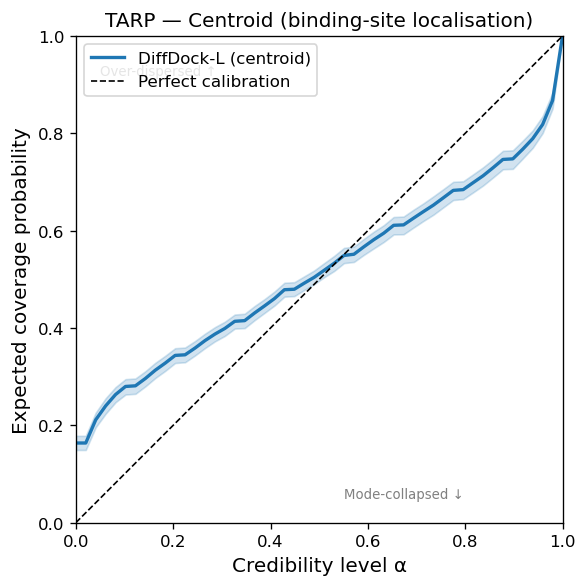

In [22]:
from molcalib.tarp import bootstrap_ecp
ecp_c, alpha_c = ecp_from_fractions(f_centroid, n_bins=50)
boot_c = bootstrap_ecp(f_centroid, n_bootstrap=500)

fig, ax = plt.subplots(figsize=(5, 5))
plot_ecp(ecp_c, alpha_c, ax=ax, label="DiffDock-L (centroid)", color="C0", bootstrap_ecps=boot_c)
ax.set_title("TARP — Centroid (binding-site localisation)")
plt.tight_layout()
plt.savefig(f"{FIGURES}/tarp_ecp_centroid.png", dpi=150, bbox_inches='tight')
plt.show()

## Phase 2 — Full RMSD TARP

Uses symmetry-corrected RMSD (spyrmsd) over all heavy atoms. Tests full 3D pose calibration including orientation and torsion angles.

> **Runtime:** ~20–40 min for K=100 on CPU. Run the cell below on a compute node, or reduce K for a quick check.

In [23]:
# Set K=10 for a fast local test; use K=100 for the full result (run on compute node)
K_RMSD = 10  # increase to 100 for publication-quality results

if not os.path.exists(f"{METRICS}/tarp_fractions_symrmsd_K{K_RMSD}.npy"):
    f_rmsd = run_tarp_eval(
        complex_names, results_index, DATA_DIR,
        K=K_RMSD, mode="rmsd", seed=42, verbose=True, n_workers=1
    )
    np.save(f"{METRICS}/tarp_fractions_symrmsd_K{K_RMSD}.npy", f_rmsd)
else: 
    f_rmsd = np.load(f"{METRICS}/tarp_fractions_symrmsd_K{K_RMSD}.npy")
    

print(f"Collected {f_rmsd.shape[0]} complexes × {f_rmsd.shape[1]} references")

Collected 321 complexes × 10 references


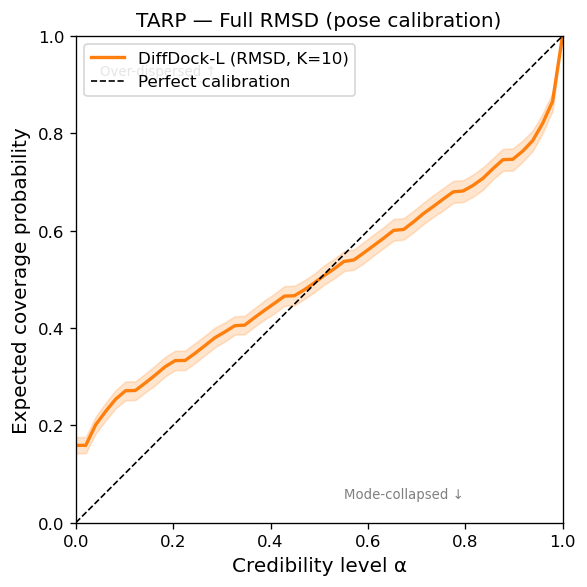

In [24]:
# from molcalib.tarp import bootstrap_ecp

ecp_r, alpha_r = ecp_from_fractions(f_rmsd, n_bins=50)
boot_r = bootstrap_ecp(f_rmsd, n_bootstrap=500)

fig, ax = plt.subplots(figsize=(5, 5))
plot_ecp(ecp_r, alpha_r, ax=ax, label=f"DiffDock-L (RMSD, K={K_RMSD})", color="C1", bootstrap_ecps=boot_r)
ax.set_title("TARP — Full RMSD (pose calibration)")
plt.tight_layout()
plt.savefig(f"{FIGURES}/tarp_ecp_rmsd.png", dpi=150, bbox_inches='tight')
plt.show()

## Combined plot

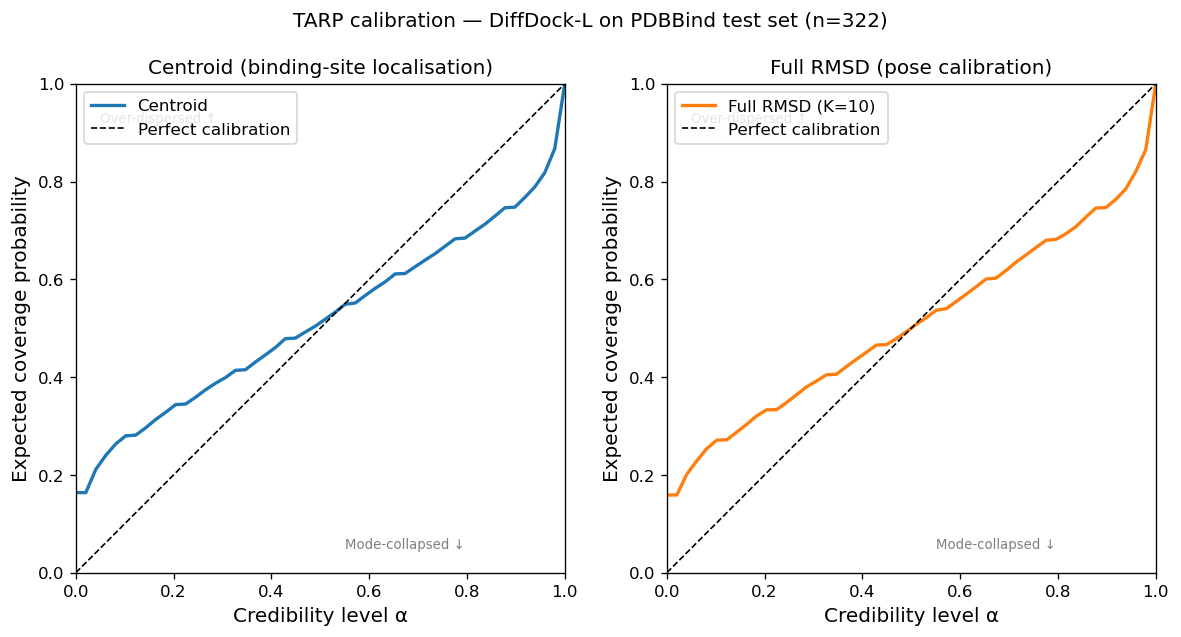

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_ecp(ecp_c, alpha_c, ax=axes[0], label="Centroid", color="C0")
axes[0].set_title("Centroid (binding-site localisation)")
plot_ecp(ecp_r, alpha_r, ax=axes[1], label=f"Full RMSD (K={K_RMSD})", color="C1")
axes[1].set_title("Full RMSD (pose calibration)")
plt.suptitle("TARP calibration — DiffDock-L on PDBBind test set (n=322)", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES}/tarp_ecp_combined.png", dpi=150, bbox_inches='tight')
plt.show()



## Per-complex coverage distribution

For each complex, compute the mean coverage fraction (average f over K references). High mean f = over-dispersed for that complex; low mean f = mode-collapsed.

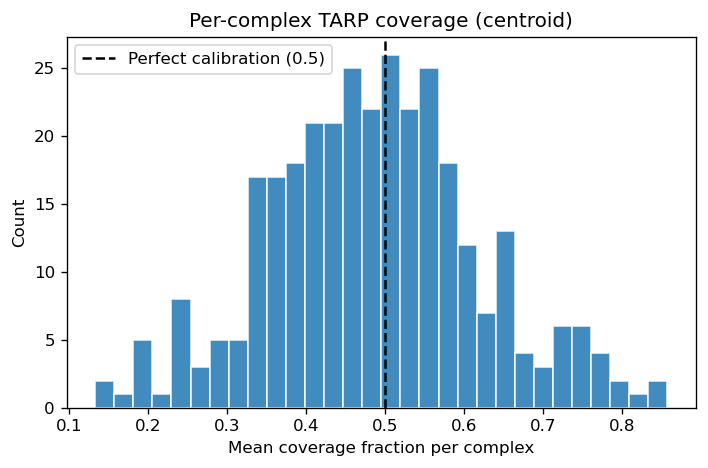

Complexes with mean f > 0.5 (over-dispersed): 46.3%
Complexes with mean f < 0.5 (mode-collapsed): 53.4%


In [26]:
# Reshape fractions back to (n_complexes, K)
# f_centroid is already (n_complexes, K) — no reshape needed
mean_f_per_complex = np.nanmean(f_centroid, axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(mean_f_per_complex, bins=30, color="C0", edgecolor="white", alpha=0.85)
ax.axvline(0.5, color="k", linestyle="--", label="Perfect calibration (0.5)")
ax.set_xlabel("Mean coverage fraction per complex")
ax.set_ylabel("Count")
ax.set_title("Per-complex TARP coverage (centroid)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/tarp_per_complex_hist.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Complexes with mean f > 0.5 (over-dispersed): {(mean_f_per_complex > 0.5).mean()*100:.1f}%")
print(f"Complexes with mean f < 0.5 (mode-collapsed): {(mean_f_per_complex < 0.5).mean()*100:.1f}%")

## Top-1 RMSD — success rate curve

For each complex, takes the single top-ranked prediction (by confidence score) and computes its symmetry-corrected RMSD to the crystal structure. Plots the cumulative fraction of complexes below each RMSD threshold — the standard docking benchmark plot. A prediction is conventionally considered a success at < 2 Å.

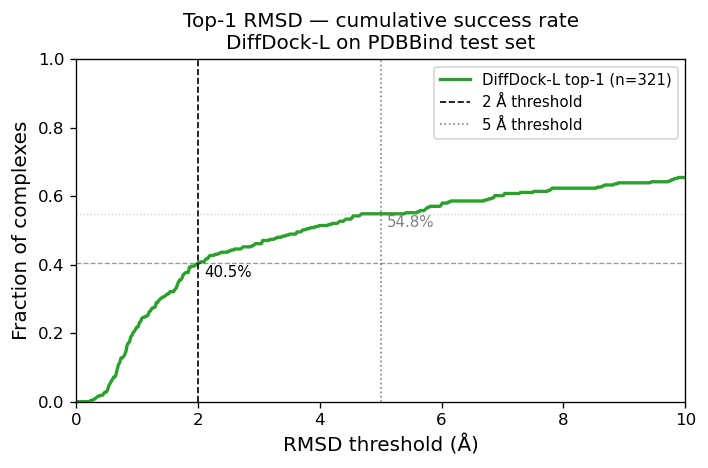

Median RMSD:    3.72 Å
Mean RMSD:      12.85 Å
Fraction < 2 Å: 0.405
Fraction < 5 Å: 0.548


In [27]:
top1_rmsd = np.load(f"{METRICS}/top1_rmsd.npy")
valid = top1_rmsd[np.isfinite(top1_rmsd)]

thresholds = np.linspace(0, 10, 500)
cdf = np.array([(valid < t).mean() for t in thresholds])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, cdf, color="C2", lw=2, label=f"DiffDock-L top-1 (n={len(valid)})")
ax.axvline(2, color="k", linestyle="--", lw=1, label="2 Å threshold")
ax.axvline(5, color="grey", linestyle=":", lw=1, label="5 Å threshold")
ax.axhline((valid < 2).mean(), color="k", linestyle="--", lw=0.8, alpha=0.4)
ax.axhline((valid < 5).mean(), color="grey", linestyle=":", lw=0.8, alpha=0.4)

ax.text(2.1, (valid < 2).mean() - 0.04, f"{(valid < 2).mean()*100:.1f}%", fontsize=9, color="k")
ax.text(5.1, (valid < 5).mean() - 0.04, f"{(valid < 5).mean()*100:.1f}%", fontsize=9, color="grey")

ax.set_xlabel("RMSD threshold (Å)", fontsize=12)
ax.set_ylabel("Fraction of complexes", fontsize=12)
ax.set_title("Top-1 RMSD — cumulative success rate\nDiffDock-L on PDBBind test set")
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES}/top1_rmsd_cdf.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Median RMSD:    {np.median(valid):.2f} Å")
print(f"Mean RMSD:      {np.mean(valid):.2f} Å")
print(f"Fraction < 2 Å: {(valid < 2).mean():.3f}")
print(f"Fraction < 5 Å: {(valid < 5).mean():.3f}")

## TARP by Protein Family — RMSD

Uses the pre-computed `tarp_fractions_symrmsd_K1.npy` (K=1 reference point, all 40 samples, 321 complexes).
Groups complexes into 7 biologically meaningful families via `pdb_annotations.csv` and plots per-group ECP curves.

> **Note:** The RMSD file has 321 rows vs 322 complex names. The K=1 job ran on a slightly older 321-entry list (same order, same first/last complex). The one tail complex is excluded from this analysis.

Group                     N
------------------------------
Hydrolases               69
Transferases             82
Sugar Binding            28
Signaling                22
Transcription/Gene       33
Oxidoreductases           9
Other                    78

ALL (baseline)          321


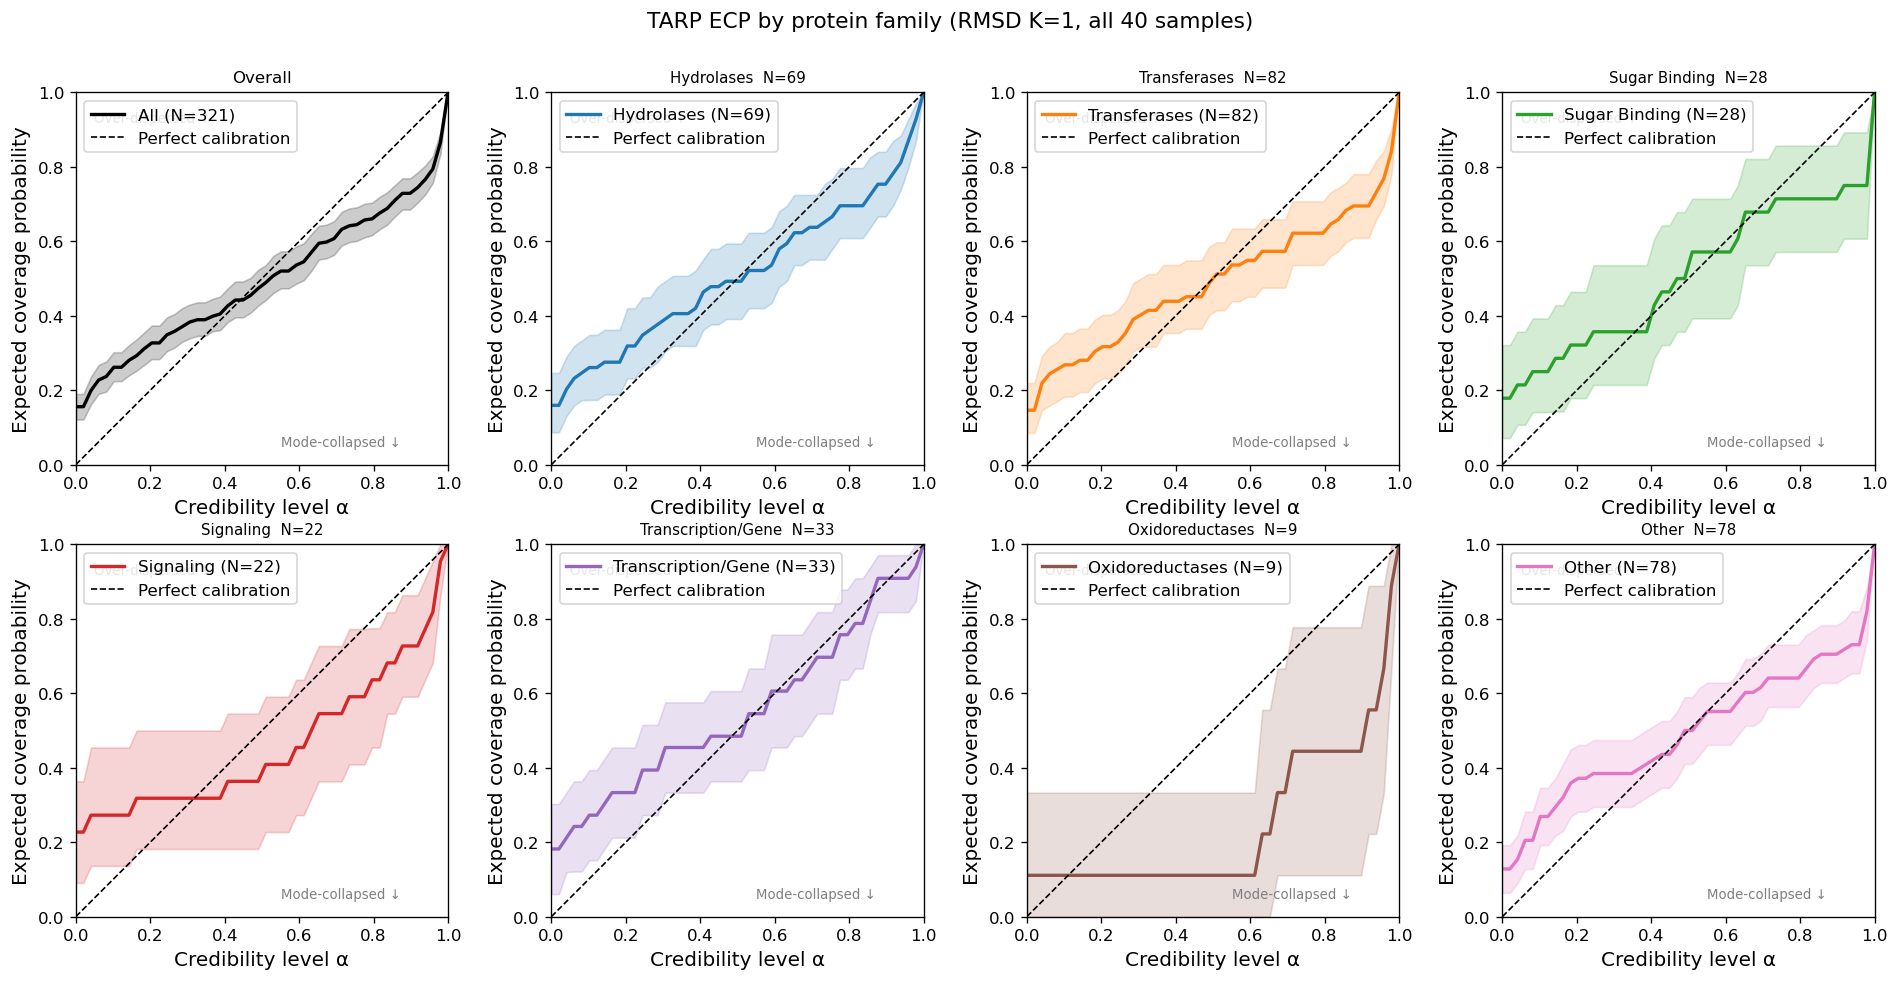

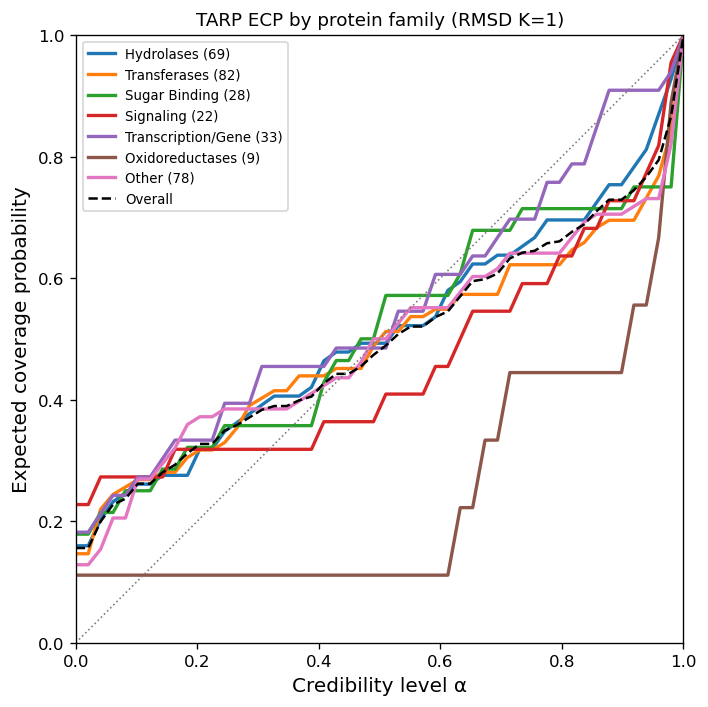

In [28]:
import pandas as pd
from molcalib.tarp import bootstrap_ecp

# --- Load pre-computed RMSD fractions ---
f_rmsd_k1 = np.load(f"{METRICS}/tarp_fractions_symrmsd_K1.npy")   # (321, 1)
names_rmsd = complex_names[:321]                                # same order, one tail name excluded

# --- Protein annotations ---
ann = pd.read_csv("/home/qf226/rds/hpc-work/data/inference/pdb_annotations.csv")
ann_map = dict(zip(ann["pdb_id"], ann["protein_class"].fillna("Unknown")))

# --- Group definitions (first match wins) ---
GROUPS = [
    ("Hydrolases",         lambda c: "hydrolase"    in c.lower()),
    ("Transferases",       lambda c: "transferase"  in c.lower()),
    ("Sugar Binding",      lambda c: "sugar binding" in c.lower()),
    ("Signaling",          lambda c: "signaling"    in c.lower()),
    ("Transcription/Gene", lambda c: any(k in c.lower() for k in
                                         ("transcription", "nuclear protein",
                                          "dna binding", "rna binding", "gene regulation"))),
    ("Oxidoreductases",    lambda c: "oxidoreductase" in c.lower()),
    ("Other",              lambda c: True),
]
COLORS = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

def assign_group(prot_class):
    for name, fn in GROUPS:
        if fn(prot_class):
            return name
    return "Other"

group_labels = np.array([assign_group(ann_map.get(n, "Unknown")) for n in names_rmsd])

# --- Per-group ECP + ATC ---
rng = np.random.default_rng(42)
group_results = {}
print(f"{'Group':<22} {'N':>4}")
print("-" * 30)

for grp_name, _ in GROUPS:
    mask = group_labels == grp_name
    n = mask.sum()
    if n == 0:
        continue
    f_grp = f_rmsd_k1[mask]
    ecp, alpha = ecp_from_fractions(f_grp)
    boot = bootstrap_ecp(f_grp, n_bootstrap=500, rng=rng)
    group_results[grp_name] = dict(n=n, f=f_grp, ecp=ecp, alpha=alpha, boot=boot)
    print(f"{grp_name:<22} {n:>4}")

ecp_all, alpha_all = ecp_from_fractions(f_rmsd_k1)
boot_all = bootstrap_ecp(f_rmsd_k1, n_bootstrap=500, rng=rng)
print(f"\n{'ALL (baseline)':<22} {len(names_rmsd):>4}")

# --- Panel plot ---
ncols, n_groups = 4, len(group_results)
nrows = (n_groups + 1 + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.ravel()

plot_ecp(ecp_all, alpha_all, ax=axes[0], label=f"All (N={len(names_rmsd)})",
         color="black", bootstrap_ecps=boot_all)
axes[0].set_title("Overall", fontsize=10)

for i, ((grp_name, _), color) in enumerate(zip(group_results.items(), COLORS)):
    res = group_results[grp_name]
    plot_ecp(res["ecp"], res["alpha"], ax=axes[i + 1],
             label=f"{grp_name} (N={res['n']})", color=color, bootstrap_ecps=res["boot"])
    axes[i + 1].set_title(f"{grp_name}  N={res['n']}", fontsize=9)

for j in range(i + 2, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("TARP ECP by protein family (RMSD K=1, all 40 samples)", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig(f"{FIGURES}/tarp_ecp_rmsd_by_group_panels.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Overlay plot ---
fig2, ax2 = plt.subplots(figsize=(6, 6))
for (grp_name, _), color in zip(group_results.items(), COLORS):
    res = group_results[grp_name]
    ax2.plot(res["alpha"], res["ecp"], color=color, lw=2,
             label=f"{grp_name} ({res['n']})")
ax2.plot(alpha_all, ecp_all, "k--", lw=1.5, label="Overall")
ax2.plot([0, 1], [0, 1], "grey", lw=1, ls=":")
ax2.set_xlabel("Credibility level α", fontsize=12)
ax2.set_ylabel("Expected coverage probability", fontsize=12)
ax2.set_title("TARP ECP by protein family (RMSD K=1)", fontsize=11)
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect("equal")
ax2.legend(fontsize=8, loc="upper left")
fig2.tight_layout()
fig2.savefig(f"{FIGURES}/tarp_ecp_rmsd_by_group_overlay.png", dpi=150, bbox_inches="tight")
plt.show()


## MIRA Score by Protein Family

MIRA (Sharief et al. 2026) tests calibration by drawing random centers in the full all-atom coordinate space and checking whether the crystal pose falls inside the same ball as DiffDock's predicted samples.

**Reference value ≈ 0.683** for S=40 samples (Beta(2,1) null).  
Score **above 0.683** = over-dispersed. Score **below 0.683** = mode-collapsed.

Distance metric: per-atom RMSD (Euclidean in flat coordinate space divided by √n_atoms). Run per-complex (T=1 each, different atom counts), aggregated externally. Group error bars from bootstrapping over per-complex scores. X-axis labels include % of complexes with best-of-40 RMSD < 2 Å.

In [34]:
from eval_diffdock.mira_runner import compute_mira_scores, compute_rmsd_accuracy
from molcalib.mira import mira_null, bootstrap_mira_groups

MIRA_SCORES_PATH = f"{METRICS}/mira_scores_symrmsd.npy"
MIRA_NAMES_PATH  = f"{METRICS}/mira_names_symrmsd.npy"
RMSD_ACC_PATH    = f"{METRICS}/rmsd_accuracy.npz"

if os.path.exists(MIRA_SCORES_PATH):
    mira_names  = np.load(MIRA_NAMES_PATH,  allow_pickle=True)
    mira_scores = np.load(MIRA_SCORES_PATH)
    print(f"Loaded cached MIRA scores ({len(mira_scores)} complexes)")
else:
    mira_names, mira_scores = compute_mira_scores(
        complex_names, results_index, DATA_DIR,
        num_runs=100, verbose=True, metric="rmsd",
    )
    np.save(MIRA_NAMES_PATH,  mira_names)
    np.save(MIRA_SCORES_PATH, mira_scores)

if os.path.exists(RMSD_ACC_PATH):
    _acc = np.load(RMSD_ACC_PATH, allow_pickle=True)
    rmsd_acc_names = _acc["names"]
    rmsd_acc_min   = _acc["min_rmsds"]
    rmsd_acc_fracs = _acc["fracs"]
    print(f"Loaded cached RMSD accuracy ({len(rmsd_acc_names)} complexes)")
else:
    rmsd_acc_names, rmsd_acc_min, rmsd_acc_fracs = compute_rmsd_accuracy(
        complex_names, results_index, DATA_DIR,
        thresholds=(2.0, 5.0), verbose=True,
    )
    np.savez(RMSD_ACC_PATH, names=rmsd_acc_names, min_rmsds=rmsd_acc_min, fracs=rmsd_acc_fracs)

REF = mira_null(S=40)
print(f"\nOverall MIRA score: {mira_scores.mean():.4f} ± {mira_scores.std():.4f}")
print(f"Reference (perfect calibration): {REF:.4f}")
overall_pct_2 = (rmsd_acc_min < 2.0).mean() * 100
overall_pct_5 = (rmsd_acc_min < 5.0).mean() * 100
print(f"Overall RMSD accuracy: {overall_pct_2:.1f}% <2Å, {overall_pct_5:.1f}% <5Å  (best-of-N)")

Loaded cached MIRA scores (322 complexes)
Loaded cached RMSD accuracy (322 complexes)

Overall MIRA score: 0.6189 ± 0.0855
Reference (perfect calibration): 0.6833
Overall RMSD accuracy: 55.9% <2Å, 78.3% <5Å  (best-of-N)


Group                     N    MIRA score              90% CI     <2Å%          vs ref
--------------------------------------------------------------------------------------
Hydrolases               69        0.6201  [0.5992, 0.6381]    72.5%  mode-collapsed
Transferases             82        0.6063  [0.5908, 0.6207]    54.9%  mode-collapsed
Sugar Binding            28        0.6002  [0.5696, 0.6274]    53.6%  mode-collapsed
Signaling                22        0.6414  [0.6147, 0.6714]    31.8%  mode-collapsed
Transcription/Gene       33        0.6549  [0.6365, 0.6720]    81.8%  mode-collapsed
Oxidoreductases           9        0.6112  [0.5672, 0.6542]    11.1%  mode-collapsed
Other                    79        0.6173  [0.6023, 0.6334]    44.3%  mode-collapsed

Overall                 322        0.6189  [0.6120, 0.6269]  55.9%
Reference                          0.6833


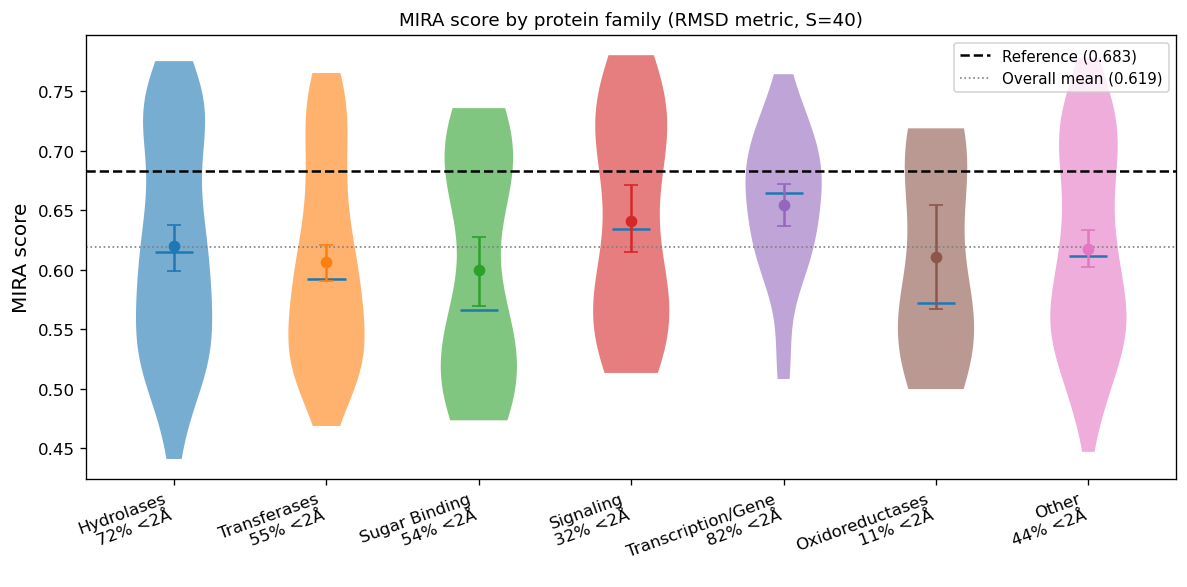

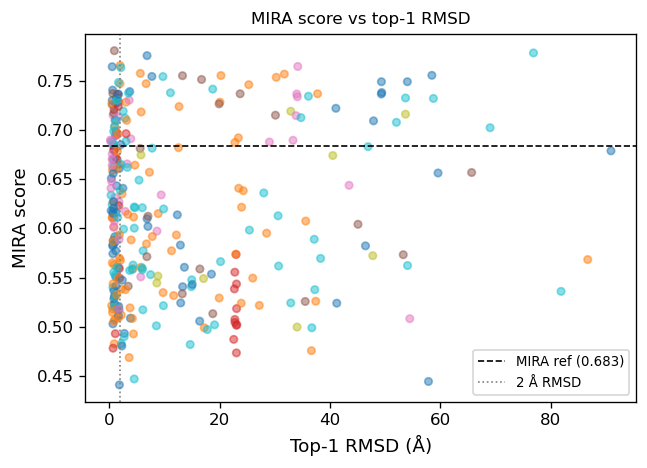

In [30]:
import pandas as pd

# --- Assign protein groups (same definitions as TARP section) ---
ann     = pd.read_csv("/home/qf226/rds/hpc-work/data/inference/pdb_annotations.csv")
ann_map = dict(zip(ann["pdb_id"], ann["protein_class"].fillna("Unknown")))

GROUPS = [
    ("Hydrolases",         lambda c: "hydrolase"     in c.lower()),
    ("Transferases",       lambda c: "transferase"   in c.lower()),
    ("Sugar Binding",      lambda c: "sugar binding" in c.lower()),
    ("Signaling",          lambda c: "signaling"     in c.lower()),
    ("Transcription/Gene", lambda c: any(k in c.lower() for k in
                                         ("transcription", "nuclear protein",
                                          "dna binding", "rna binding", "gene regulation"))),
    ("Oxidoreductases",    lambda c: "oxidoreductase" in c.lower()),
    ("Other",              lambda c: True),
]
GROUP_NAMES = [g[0] for g in GROUPS]
COLORS      = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

def assign_group(pc):
    for name, fn in GROUPS:
        if fn(pc): return name
    return "Other"

mira_group_labels = np.array([assign_group(ann_map.get(n, "Unknown")) for n in mira_names])

# --- Per-group RMSD accuracy (best-of-N: fraction of complexes with min RMSD < 2 Å) ---
rmsd_group_labels = np.array([assign_group(ann_map.get(n, "Unknown")) for n in rmsd_acc_names])
rmsd_lt2_map = {}
for grp in GROUP_NAMES:
    mask = rmsd_group_labels == grp
    if mask.sum() == 0:
        rmsd_lt2_map[grp] = np.nan
        continue
    rmsd_lt2_map[grp] = (rmsd_acc_min[mask] < 2.0).mean() * 100  # percent

# --- Bootstrap per-group MIRA stats ---
rng         = np.random.default_rng(42)
group_stats = bootstrap_mira_groups(mira_scores, mira_group_labels, GROUP_NAMES,
                                    n_bootstrap=500, rng=rng)

# --- Print table ---
print(f"{'Group':<22} {'N':>4}  {'MIRA score':>12}  {'90% CI':>18}  {'<2Å%':>7}  {'vs ref':>14}")
print("-" * 86)
for grp in GROUP_NAMES:
    if grp not in group_stats: continue
    s = group_stats[grp]
    diff = s['mean'] - REF
    direction = "over-dispersed" if diff > 0.01 else "mode-collapsed" if diff < -0.01 else "calibrated"
    pct = rmsd_lt2_map.get(grp, np.nan)
    pct_str = f"{pct:.1f}%" if np.isfinite(pct) else "N/A"
    print(f"{grp:<22} {s['n']:>4}  {s['mean']:>12.4f}  "
          f"[{s['lo']:.4f}, {s['hi']:.4f}]  {pct_str:>7}  {direction}")
overall_lo = np.percentile(
    [np.random.default_rng(42+b).choice(mira_scores, size=len(mira_scores), replace=True).mean()
     for b in range(500)], [5, 95])
print(f"\n{'Overall':<22} {len(mira_scores):>4}  {mira_scores.mean():>12.4f}  "
      f"[{overall_lo[0]:.4f}, {overall_lo[1]:.4f}]  {overall_pct_2:.1f}%")
print(f"{'Reference':22}       {REF:>12.4f}")

# --- Figure 1: violin plot per group ---
fig, ax = plt.subplots(figsize=(10, 5))
data_by_group  = [mira_scores[mira_group_labels == g] for g in GROUP_NAMES
                  if (mira_group_labels == g).any()]
present_groups = [g for g in GROUP_NAMES if (mira_group_labels == g).any()]
vp = ax.violinplot(data_by_group, positions=np.arange(len(present_groups)),
                   showmedians=True, showextrema=False)
for pc, color in zip(vp["bodies"], COLORS):
    pc.set_facecolor(color); pc.set_alpha(0.6)
for i, (grp, color) in enumerate(zip(present_groups, COLORS)):
    s = group_stats[grp]
    ax.errorbar(i, s["mean"], yerr=[[s["mean"]-s["lo"]], [s["hi"]-s["mean"]]],
                fmt="o", color=color, capsize=4, ms=6, zorder=5)
ax.axhline(REF, color="black", lw=1.5, ls="--", label=f"Reference ({REF:.3f})")
ax.axhline(mira_scores.mean(), color="grey", lw=1, ls=":", label=f"Overall mean ({mira_scores.mean():.3f})")
ax.set_xticks(np.arange(len(present_groups)))
tick_labels = [
    f"{g}\n{rmsd_lt2_map[g]:.0f}% <2Å" if np.isfinite(rmsd_lt2_map.get(g, np.nan)) else g
    for g in present_groups
]
ax.set_xticklabels(tick_labels, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("MIRA score", fontsize=12)
ax.set_title("MIRA score by protein family (RMSD metric, S=40)", fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f"{FIGURES}/mira_by_group_violin.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Figure 2: MIRA score vs top-1 RMSD scatter + MIRA vs TARP comparison ---
top1_rmsd = np.load(f"{METRICS}/top1_rmsd.npy")
top1_map  = dict(zip(complex_names, top1_rmsd))
mira_top1 = np.array([top1_map.get(n, np.nan) for n in mira_names])
valid = np.isfinite(mira_top1)

fig2, ax = plt.subplots(figsize=(5.5, 4))

ax.scatter(mira_top1[valid], mira_scores[valid],
           c=[list(GROUP_NAMES).index(g) if g in GROUP_NAMES else 6
              for g in mira_group_labels[valid]],
           cmap="tab10", alpha=0.5, s=20)
ax.axhline(REF, color="black", lw=1, ls="--", label=f"MIRA ref ({REF:.3f})")
ax.axvline(2,   color="grey",  lw=1, ls=":",  label="2 Å RMSD")
ax.set_xlabel("Top-1 RMSD (Å)", fontsize=11)
ax.set_ylabel("MIRA score", fontsize=11)
ax.set_title("MIRA score vs top-1 RMSD", fontsize=10)
ax.legend(fontsize=8)


fig2.tight_layout()
fig2.savefig(f"{FIGURES}/mira_by_group.png", dpi=150, bbox_inches="tight")
plt.show()

## PoseBusters — Physical Validity Filtering

[PoseBusters](https://github.com/maabuu/posebusters) (Buttenschoen et al., *Chemical Science* 2024) validates each docked pose using ~20 checks:

- **Chemical**: RDKit sanitization, connectivity, formula/bond preservation, chirality, stereo geometry
- **Intramolecular**: bond lengths/angles within distance-geometry bounds, ring/double-bond planarity, no internal steric clashes, energy ratio < 100× ensemble average
- **Intermolecular**: no volume overlap with protein (>7.5%), minimum protein–ligand distance ratio > 0.75 × vdW sum

We use **`config="dock"`** — no reference crystal pose is needed, so filtering is based purely on physical plausibility of each predicted pose in the pocket.

**Questions answered below:**
1. What fraction of DiffDock poses are physically valid?
2. How does RMSD accuracy (% < 2 Å) change after discarding invalid poses?
3. How does the MIRA calibration score change on the filtered pose set?

In [32]:
import json
from pathlib import Path
from eval_diffdock.pb_eval import run_posebusters

PB_CACHE = f"{METRICS}/posebusters_results.json"

pb_results = run_posebusters(
    complex_names, POSES_DIR, DATA_DIR,
    config="dock", cache_path=PB_CACHE, verbose=True, max_complexes = 10
)

# ── Summary statistics ────────────────────────────────────────────────────────
n_total_all   = sum(v["n_total"]           for v in pb_results.values())
n_valid_all   = sum(len(v["valid_ranks"])  for v in pb_results.values())
n_cplx_any    = sum(1 for v in pb_results.values() if v["valid_ranks"])
n_cplx_top1   = sum(
    1 for v in pb_results.values()
    if "rank1.sdf" in v.get("valid_ranks", [])
)

print(f"Complexes processed:                {len(pb_results)}")
print(f"Complexes with ≥1 PB-valid pose:    {n_cplx_any}  ({n_cplx_any/len(pb_results)*100:.1f}%)")
print(f"Complexes where top-1 is PB-valid:  {n_cplx_top1}  ({n_cplx_top1/len(pb_results)*100:.1f}%)")
print(f"Total poses evaluated:              {n_total_all}")
print(f"PB-valid poses:                     {n_valid_all}  ({n_valid_all/n_total_all*100:.1f}%)")

# ── Per-check failure rates ───────────────────────────────────────────────────
all_failures = {}
for v in pb_results.values():
    for check, cnt in v.get("check_failures", {}).items():
        all_failures[check] = all_failures.get(check, 0) + cnt

sorted_failures = sorted(all_failures.items(), key=lambda x: -x[1])
print(f"\nTop failure modes (out of {n_total_all} poses):")
for check, cnt in sorted_failures[:12]:
    print(f"  {check:<48}  {cnt:>5}  ({cnt/n_total_all*100:.1f}%)")

ModuleNotFoundError: No module named 'posebusters'

In [33]:
from eval_diffdock.pb_eval import compute_rmsd_accuracy_filtered

PB_RMSD_ACC_PATH = f"{METRICS}/pb_rmsd_accuracy.npz"

if os.path.exists(PB_RMSD_ACC_PATH):
    _acc = np.load(PB_RMSD_ACC_PATH, allow_pickle=True)
    pb_acc_names = _acc["names"]
    pb_acc_min   = _acc["min_rmsds"]
    pb_acc_fracs = _acc["fracs"]
    print(f"Loaded cached PB-filtered RMSD accuracy ({len(pb_acc_names)} complexes)")
else:
    pb_acc_names, pb_acc_min, pb_acc_fracs = compute_rmsd_accuracy_filtered(
        complex_names, pb_results, POSES_DIR, DATA_DIR,
        thresholds=(2.0, 5.0), verbose=True,
    )
    np.savez(PB_RMSD_ACC_PATH,
             names=pb_acc_names, min_rmsds=pb_acc_min, fracs=pb_acc_fracs)

# ── Before vs after ───────────────────────────────────────────────────────────
before_pct_2 = (rmsd_acc_min < 2.0).mean() * 100
before_pct_5 = (rmsd_acc_min < 5.0).mean() * 100
after_pct_2  = (pb_acc_min   < 2.0).mean() * 100
after_pct_5  = (pb_acc_min   < 5.0).mean() * 100

# Top-1 specific: is rank1.sdf PB-valid for each complex?
top1_rmsd_all = np.load(f"{METRICS}/top1_rmsd.npy")
top1_valid = np.array([
    "rank1.sdf" in pb_results.get(n, {}).get("valid_ranks", [])
    for n in complex_names
])
top1_pct_2_before = (top1_rmsd_all < 2.0).mean() * 100
# Fraction of ALL complexes where top-1 is both PB-valid and RMSD < 2 Å
top1_pct_2_after  = (top1_valid & (top1_rmsd_all < 2.0)).mean() * 100

print("Performance impact of PoseBusters filtering")
print("=" * 52)
print(f"\n  Best-of-N RMSD < 2 Å:   {before_pct_2:.1f}%  →  {after_pct_2:.1f}%  (Δ = {after_pct_2-before_pct_2:+.1f}%)")
print(f"  Best-of-N RMSD < 5 Å:   {before_pct_5:.1f}%  →  {after_pct_5:.1f}%  (Δ = {after_pct_5-before_pct_5:+.1f}%)")
print(f"\n  Top-1 RMSD < 2 Å (all complexes):          {top1_pct_2_before:.1f}%")
print(f"  Top-1 PB-valid AND RMSD < 2 Å:              {top1_pct_2_after:.1f}%  (Δ = {top1_pct_2_after-top1_pct_2_before:+.1f}%)")
print(f"\n  Top-1 poses that are PB-valid:              {top1_valid.mean()*100:.1f}%")
print(f"  Complexes with ≥1 PB-valid pose:            "
      f"{sum(1 for v in pb_results.values() if v['valid_ranks'])/len(pb_results)*100:.1f}%")

# ── CDF comparison plot ───────────────────────────────────────────────────────
thresholds = np.linspace(0, 10, 500)
before_cdf = np.array([(rmsd_acc_min < t).mean() for t in thresholds]) * 100
after_cdf  = np.array([(pb_acc_min   < t).mean() for t in thresholds]) * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, before_cdf, color="C2", lw=2,
        label=f"Before PB — all poses  ({before_pct_2:.1f}% < 2 Å, n={len(rmsd_acc_min)})")
ax.plot(thresholds, after_cdf,  color="C3", lw=2, ls="--",
        label=f"After PB  — valid only ({after_pct_2:.1f}% < 2 Å, n={len(pb_acc_min)})")
ax.axvline(2, color="k",    ls="--", lw=1)
ax.axvline(5, color="grey", ls=":",  lw=1)
ax.set_xlabel("RMSD threshold (Å)", fontsize=12)
ax.set_ylabel("% complexes below threshold", fontsize=12)
ax.set_title("Best-of-N RMSD accuracy — before vs after PoseBusters filtering\n"
             "DiffDock-L on PDBBind test set", fontsize=11)
ax.set_xlim(0, 10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES}/pb_rmsd_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'pb_results' is not defined

In [ ]:
from eval_diffdock.pb_eval import compute_mira_filtered
from molcalib.mira import mira_null, bootstrap_mira_groups

PB_MIRA_SCORES_PATH = f"{METRICS}/pb_mira_scores.npy"
PB_MIRA_NAMES_PATH  = f"{METRICS}/pb_mira_names.npy"
REF = mira_null(S=40)

if os.path.exists(PB_MIRA_SCORES_PATH):
    pb_mira_names  = np.load(PB_MIRA_NAMES_PATH,  allow_pickle=True)
    pb_mira_scores = np.load(PB_MIRA_SCORES_PATH)
    print(f"Loaded cached PB-filtered MIRA scores ({len(pb_mira_scores)} complexes)")
else:
    pb_mira_names, pb_mira_scores = compute_mira_filtered(
        complex_names, pb_results, POSES_DIR, DATA_DIR,
        num_runs=100, verbose=True, metric="rmsd",
    )
    np.save(PB_MIRA_NAMES_PATH,  pb_mira_names)
    np.save(PB_MIRA_SCORES_PATH, pb_mira_scores)

# ── Overall comparison ────────────────────────────────────────────────────────
print(f"\nMIRA score comparison:")
print(f"  Before PB (all poses):    {mira_scores.mean():.4f} ± {mira_scores.std():.4f}  "
      f"(n={len(mira_scores)})")
print(f"  After  PB (valid only):   {pb_mira_scores.mean():.4f} ± {pb_mira_scores.std():.4f}  "
      f"(n={len(pb_mira_scores)})")
print(f"  Reference (S=40):         {REF:.4f}")

# Matched comparison: same set of complexes present in both runs
common_names = set(mira_names) & set(pb_mira_names)
idx_before   = {n: i for i, n in enumerate(mira_names)}
idx_after    = {n: i for i, n in enumerate(pb_mira_names)}
before_cmn   = np.array([mira_scores[idx_before[n]]    for n in common_names])
after_cmn    = np.array([pb_mira_scores[idx_after[n]]  for n in common_names])
print(f"\n  Matched ({len(common_names)} complexes in both):")
print(f"    Before: {before_cmn.mean():.4f}")
print(f"    After:  {after_cmn.mean():.4f}")
print(f"    Change: {after_cmn.mean()-before_cmn.mean():+.4f}")

# ── Per-group breakdown (same groups as rest of notebook) ─────────────────────
import pandas as pd
ann     = pd.read_csv("/home/qf226/rds/hpc-work/data/inference/pdb_annotations.csv")
ann_map = dict(zip(ann["pdb_id"], ann["protein_class"].fillna("Unknown")))

GROUPS = [
    ("Hydrolases",         lambda c: "hydrolase"     in c.lower()),
    ("Transferases",       lambda c: "transferase"   in c.lower()),
    ("Sugar Binding",      lambda c: "sugar binding" in c.lower()),
    ("Signaling",          lambda c: "signaling"     in c.lower()),
    ("Transcription/Gene", lambda c: any(k in c.lower() for k in
                                         ("transcription", "nuclear protein",
                                          "dna binding", "rna binding", "gene regulation"))),
    ("Oxidoreductases",    lambda c: "oxidoreductase" in c.lower()),
    ("Other",              lambda c: True),
]
GROUP_NAMES = [g[0] for g in GROUPS]
COLORS      = ["C0", "C1", "C2", "C3", "C4", "C5", "C6"]

def assign_group(pc):
    for name, fn in GROUPS:
        if fn(pc): return name
    return "Other"

pb_group_labels = np.array([assign_group(ann_map.get(n, "Unknown")) for n in pb_mira_names])
rng = np.random.default_rng(42)
pb_group_stats = bootstrap_mira_groups(pb_mira_scores, pb_group_labels, GROUP_NAMES,
                                       n_bootstrap=500, rng=rng)

print(f"\n{'Group':<22} {'N(before)':>10} {'N(after)':>9}  "
      f"{'MIRA(before)':>13}  {'MIRA(after)':>12}  {'Change':>8}")
print("-" * 82)
for grp in GROUP_NAMES:
    if grp not in group_stats and grp not in pb_group_stats:
        continue
    sb = group_stats.get(grp, {})
    sa = pb_group_stats.get(grp, {})
    m_b = sb.get("mean", float("nan"))
    m_a = sa.get("mean", float("nan"))
    n_b = sb.get("n", 0)
    n_a = sa.get("n", 0)
    print(f"{grp:<22} {n_b:>10} {n_a:>9}  {m_b:>13.4f}  {m_a:>12.4f}  {m_a-m_b:>+8.4f}")

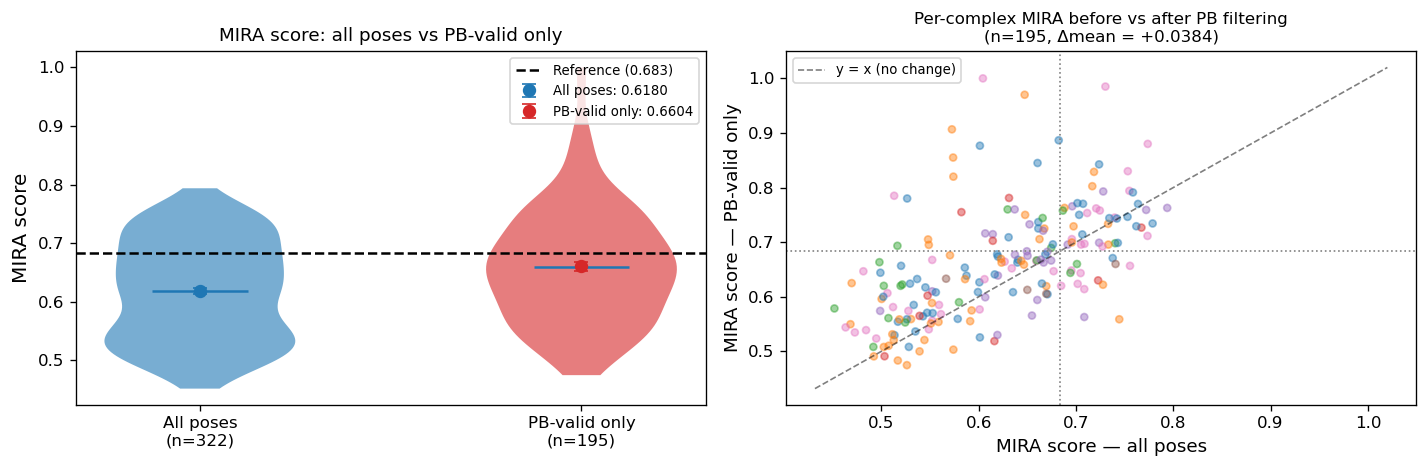

In [15]:
# ── Violin: MIRA before vs after PB filtering ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
vp = ax.violinplot([mira_scores, pb_mira_scores], positions=[0, 1],
                   showmedians=True, showextrema=False)
vp["bodies"][0].set_facecolor("C0"); vp["bodies"][0].set_alpha(0.6)
vp["bodies"][1].set_facecolor("C3"); vp["bodies"][1].set_alpha(0.6)
for i, (d, label) in enumerate(zip(
        [mira_scores, pb_mira_scores],
        [f"All poses\n(n={len(mira_scores)})",
         f"PB-valid only\n(n={len(pb_mira_scores)})"])):
    ax.errorbar(i, d.mean(), yerr=d.std() / np.sqrt(len(d)),
                fmt="o", color=["C0", "C3"][i], capsize=4, ms=7, zorder=5,
                label=f"{label.split(chr(10))[0]}: {d.mean():.4f}")
ax.axhline(REF, color="k", ls="--", lw=1.5, label=f"Reference ({REF:.3f})")
ax.set_xticks([0, 1])
ax.set_xticklabels([f"All poses\n(n={len(mira_scores)})",
                    f"PB-valid only\n(n={len(pb_mira_scores)})"], fontsize=10)
ax.set_ylabel("MIRA score", fontsize=12)
ax.set_title("MIRA score: all poses vs PB-valid only", fontsize=11)
ax.legend(fontsize=8)

# ── Scatter: per-complex MIRA before vs after ────────────────────────────────
ax2 = axes[1]
common_list = list(common_names)
x = np.array([mira_scores[idx_before[n]]   for n in common_list])
y = np.array([pb_mira_scores[idx_after[n]] for n in common_list])
color_idx = [GROUP_NAMES.index(assign_group(ann_map.get(n, "Unknown")))
             if assign_group(ann_map.get(n, "Unknown")) in GROUP_NAMES else 6
             for n in common_list]
sc = ax2.scatter(x, y, c=color_idx, cmap="tab10", vmin=0, vmax=9,
                 alpha=0.45, s=18)
lims = [min(x.min(), y.min()) - 0.02, max(x.max(), y.max()) + 0.02]
ax2.plot(lims, lims, "k--", lw=1, alpha=0.5, label="y = x (no change)")
ax2.axhline(REF, color="grey", ls=":", lw=1)
ax2.axvline(REF, color="grey", ls=":", lw=1)
ax2.set_xlabel("MIRA score — all poses", fontsize=11)
ax2.set_ylabel("MIRA score — PB-valid only", fontsize=11)
ax2.set_title(f"Per-complex MIRA before vs after PB filtering\n"
              f"(n={len(common_list)}, Δmean = {y.mean()-x.mean():+.4f})", fontsize=10)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES}/pb_mira_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── MIRA comparison: all loadable poses vs PB-valid poses ───────────────────
# Left:  complexes with >=10 loadable poses, using all loadable poses.
# Right: complexes with >=10 PB-valid poses, using all valid poses.
import torch
from eval_diffdock.loader import load_crystal_coords, load_sample_coords
from eval_diffdock.mira_runner import compute_mira_one_complex as _mira_one_complex
from eval_diffdock.pb_eval import load_pb_filtered_coords

FAIR_CACHE = f"{METRICS}/mira_fair_comparison.npz"
MIN_LOAD  = 10
MIN_VALID = 10

if os.path.exists(FAIR_CACHE):
    _c = np.load(FAIR_CACHE, allow_pickle=True)
    fair_names_rand  = _c['names_rand']
    fair_scores_rand = _c['scores_rand']
    fair_names_pb    = _c['names_pb']
    fair_scores_pb   = _c['scores_pb']
    print(f"Loaded cache: {len(fair_scores_rand)} loadable, {len(fair_scores_pb)} PB-valid")
else:
    pb_eligible = set(n for n in complex_names
                      if len(pb_results.get(n, {}).get('valid_ranks', [])) >= MIN_VALID)
    print(f"All complexes: {len(complex_names)},  PB-eligible (>={MIN_VALID} valid): {len(pb_eligible)}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    names_rand, scores_rand = [], []
    names_pb,   scores_pb   = [], []

    for i, pdb_id in enumerate(complex_names):
        if i % 20 == 0:
            print(f"  [{i}/{len(complex_names)}] {pdb_id} ...", flush=True)
        try:
            _, all_crystal = load_crystal_coords(pdb_id, DATA_DIR)
            crystal = all_crystal[0]
            samples = load_sample_coords(pdb_id, results_index)
        except Exception as e:
            print(f"    Skip {pdb_id}: {e}"); continue

        # Left: all loadable poses, >=10 only
        if len(samples) >= MIN_LOAD:
            score = _mira_one_complex(crystal, samples, num_runs=100,
                                      device=device, metric='rmsd')
            if not np.isnan(score):
                names_rand.append(pdb_id); scores_rand.append(score)

        # Right: all PB-valid poses, >=10 valid only
        if pdb_id in pb_eligible:
            valid_ranks = pb_results[pdb_id]['valid_ranks']
            pb_samp = load_pb_filtered_coords(pdb_id, valid_ranks, POSES_DIR)
            score_pb = _mira_one_complex(crystal, pb_samp, num_runs=100,
                                         device=device, metric='rmsd')
            if not np.isnan(score_pb):
                names_pb.append(pdb_id); scores_pb.append(score_pb)

    fair_names_rand  = np.array(names_rand)
    fair_scores_rand = np.array(scores_rand)
    fair_names_pb    = np.array(names_pb)
    fair_scores_pb   = np.array(scores_pb)
    np.savez(FAIR_CACHE,
             names_rand=fair_names_rand, scores_rand=fair_scores_rand,
             names_pb=fair_names_pb,     scores_pb=fair_scores_pb)
    print(f"Saved: {len(fair_scores_rand)} loadable, {len(fair_scores_pb)} PB-valid")

n_valid_pb = np.array([len(pb_results.get(n, {}).get('valid_ranks', []))
                        for n in fair_names_pb])
med_S_pb  = int(np.median(n_valid_pb))
REF       = 2 / 3
print(f"\nAll loadable:     mean={fair_scores_rand.mean():.4f} "
      f"± {fair_scores_rand.std():.4f}  (n={len(fair_scores_rand)})")
print(f"PB-valid (>={MIN_VALID}): mean={fair_scores_pb.mean():.4f} "
      f"± {fair_scores_pb.std():.4f}  (n={len(fair_scores_pb)}, "
      f"median S={med_S_pb})")

# ── Violin ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
for pos, scores, color in [
    (0, fair_scores_rand, 'C0'),
    (1, fair_scores_pb,   'C3'),
]:
    vp = ax.violinplot([scores], positions=[pos], showmedians=True, showextrema=False)
    vp['bodies'][0].set_facecolor(color); vp['bodies'][0].set_alpha(0.6)
    ax.errorbar(pos, scores.mean(), yerr=scores.std() / np.sqrt(len(scores)),
                fmt='o', color=color, capsize=4, ms=7, zorder=5)
ax.axhline(REF, color='k', ls='--', lw=1.5, label=f'Reference (2/3 = {REF:.3f})')
ax.set_xticks([0, 1])
ax.set_xticklabels(
    [f'All loadable poses\n(n={len(fair_scores_rand)}, ≥{MIN_LOAD} loadable)',
     f'PB-valid only\n(n={len(fair_scores_pb)}, ≥{MIN_VALID} valid)'], fontsize=10)
ax.set_ylabel('MIRA score', fontsize=12)
ax.set_title(
    f'MIRA: all loadable poses vs PB-valid only\n'
    f'Left: ≥{MIN_LOAD} loadable (S≈40).  Right: ≥{MIN_VALID} PB-valid (median S={med_S_pb}).',
    fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES}/mira_fair_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Histograms: loadable poses (no filter) and PB-valid poses per complex ────
from eval_diffdock.loader import load_sample_coords
from rdkit import Chem
from pathlib import Path

def _count_valid_loadable(pdb_id, results_index, pb_results):
    """Count PB-valid poses that are also RDKit-parseable."""
    d = results_index[pdb_id]
    valid_names = set(pb_results.get(pdb_id, {}).get('valid_ranks', []))
    if not valid_names:
        return 0
    count = 0
    for fname in valid_names:
        sdf = d / fname
        if sdf.exists():
            mol = Chem.SDMolSupplier(str(sdf), removeHs=True)[0]
            if mol is not None:
                count += 1
    return count

N_LOADABLE_CACHE = f"{METRICS}/n_loadable.npy"
N_VALID_CACHE    = f"{METRICS}/n_valid_all.npy"

if os.path.exists(N_LOADABLE_CACHE) and os.path.exists(N_VALID_CACHE):
    n_loadable = np.load(N_LOADABLE_CACHE)
    n_valid_all = np.load(N_VALID_CACHE)
    print(f"Loaded cached pose counts ({len(n_loadable)} complexes)")
else:
    n_loadable  = np.array([len(load_sample_coords(n, results_index)) for n in complex_names])
    n_valid_all = np.array([_count_valid_loadable(n, results_index, pb_results)
                            for n in complex_names])
    np.save(N_LOADABLE_CACHE, n_loadable)
    np.save(N_VALID_CACHE, n_valid_all)
    print("Computed and cached pose counts.")

CUTOFF = 15
bins = np.arange(-0.5, CUTOFF + 2.5, 1)
tick_positions = list(range(CUTOFF + 2))
tick_labels    = [str(i) for i in range(CUTOFF + 1)] + [f'>{CUTOFF}']

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: loadable poses (no PB filter)
n_load_clipped = np.clip(n_loadable, 0, CUTOFF + 1)
axes[0].hist(n_load_clipped, bins=bins, color='C0', edgecolor='white', linewidth=0.4)
axes[0].axvline(9.5, color='C2', ls='--', lw=1.5, label='n<10: excluded from fair MIRA')
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, fontsize=9)
axes[0].set_xlabel('Number of loadable poses per complex (out of 40)', fontsize=12)
axes[0].set_ylabel('Number of complexes', fontsize=12)
axes[0].set_title(
    f'Loadable poses per complex (no filtering)\n'
    f'<10: {(n_loadable<10).sum()} ({100*(n_loadable<10).mean():.1f}%)  |  '
    f'>=10: {(n_loadable>=10).sum()} ({100*(n_loadable>=10).mean():.1f}%)  |  '
    f'all 40: {(n_loadable==40).sum()} ({100*(n_loadable==40).mean():.1f}%)',
    fontsize=10
)
axes[0].legend(fontsize=9)

# Right: PB-valid AND loadable poses
n_valid_clipped = np.clip(n_valid_all, 0, CUTOFF + 1)
axes[1].hist(n_valid_clipped, bins=bins, color='C3', edgecolor='white', linewidth=0.4)
axes[1].axvline(9.5, color='C2', ls='--', lw=1.5, label='n<10: excluded from fair MIRA')
axes[1].axvline(1.5, color='C1', ls='--', lw=1.5, label='n<2: MIRA undefined')
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, fontsize=9)
axes[1].set_xlabel('Number of PB-valid AND loadable poses per complex (out of 40)', fontsize=12)
axes[1].set_ylabel('Number of complexes', fontsize=12)
axes[1].set_title(
    f'PoseBusters-valid AND loadable poses per complex\n'
    f'0: {(n_valid_all==0).sum()} ({100*(n_valid_all==0).mean():.1f}%)  |  '
    f'<10: {(n_valid_all<10).sum()} ({100*(n_valid_all<10).mean():.1f}%)  |  '
    f'>=10: {(n_valid_all>=10).sum()} ({100*(n_valid_all>=10).mean():.1f}%)',
    fontsize=10
)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/pb_valid_poses_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Loadable — min: {n_loadable.min()}, max: {n_loadable.max()}, mean: {n_loadable.mean():.1f}")
print(f"PB-valid+loadable — min: {n_valid_all.min()}, max: {n_valid_all.max()}, mean: {n_valid_all.mean():.1f}")

## Top-1 Sampling Variance: 10 Independent Runs

The 10-run array job ran the same model 10 times independently,
each time generating 10 samples per complex. We combine them into two merged directories:

| Directory | Samples/complex | Description |
|---|---|---|
| `top1_runs_v2_top1_merged` | 10 | rank-1 pose from each of the 10 runs |
| `top1_runs_v2_top3_merged` | 30 | top-3 poses from each of the 10 runs |
| `pdbbind_testset/raw_chunks` | 40 | all poses from a single 40-sample run (baseline) |

**Key question:** Does sampling across independent runs (different random seeds) give a different
calibration signature than drawing multiple samples from a single run?

In [ ]:
TOP1_MERGED  = "/home/qf226/rds/hpc-work/results/DiffDock/top1_runs_v2_top1_merged"
TOP1_METRICS = os.path.join(TOP1_MERGED, "metrics")
TOP3_MERGED  = "/home/qf226/rds/hpc-work/results/DiffDock/top1_runs_v2_top3_merged"
TOP3_METRICS = os.path.join(TOP3_MERGED, "metrics")

# chunk_0/ lives directly inside each merged dir (no poses/ subdirectory)
index_top1 = build_results_index(TOP1_MERGED)
index_top3 = build_results_index(TOP3_MERGED)

# Restrict to complexes present in all three result sets
common = sorted(set(results_index) & set(index_top1) & set(index_top3))
print(f"40-sample baseline:      {len(results_index)} complexes")
print(f"top1_runs_v2_top1_merged: {len(index_top1)} complexes")
print(f"top1_runs_v2_top3_merged: {len(index_top3)} complexes")
print(f"Common to all three:     {len(common)} complexes")

# Verify sample counts for a spot-check complex
import random; _c = random.choice(common)
from eval_diffdock.loader import load_sample_coords
for label, idx in [("baseline", results_index), ("top1", index_top1), ("top3", index_top3)]:
    coords = load_sample_coords(_c, idx)
    print(f"  {label:12s}  {_c}: {len(coords)} poses loaded")

In [19]:
# TARP centroid on the two merged directories (fast, ~10s each)
common_names_arr = np.array(common)

CENTROID_TOP1 = f"{TOP1_METRICS}/tarp_fractions_centroid.npy"
CENTROID_TOP3 = f"{TOP3_METRICS}/tarp_fractions_centroid.npy"
CENTROID_BASE = f"{TOP1_METRICS}/tarp_fractions_centroid_baseline.npy"

if os.path.exists(CENTROID_TOP1):
    f_top1_centroid = np.load(CENTROID_TOP1)
    print(f"Loaded cached centroid TARP — top1_merged: shape={f_top1_centroid.shape}")
else:
    f_top1_centroid = run_tarp_eval(common_names_arr, index_top1, DATA_DIR, K=100, mode="centroid", seed=42, verbose=True, n_workers=1)
    np.save(CENTROID_TOP1, f_top1_centroid)

if os.path.exists(CENTROID_TOP3):
    f_top3_centroid = np.load(CENTROID_TOP3)
    print(f"Loaded cached centroid TARP — top3_merged: shape={f_top3_centroid.shape}")
else:
    f_top3_centroid = run_tarp_eval(common_names_arr, index_top3, DATA_DIR, K=100, mode="centroid", seed=42, verbose=True, n_workers=1)
    np.save(CENTROID_TOP3, f_top3_centroid)

if os.path.exists(CENTROID_BASE):
    f_base_centroid = np.load(CENTROID_BASE)
    print(f"Loaded cached centroid TARP — baseline: shape={f_base_centroid.shape}")
else:
    f_base_centroid = run_tarp_eval(common_names_arr, results_index, DATA_DIR, K=100, mode="centroid", seed=42, verbose=True, n_workers=1)
    np.save(CENTROID_BASE, f_base_centroid)

print("Done.")

Loaded cached centroid TARP — top1_merged: shape=(322, 100)
Loaded cached centroid TARP — top3_merged: shape=(322, 100)
Loaded cached centroid TARP — baseline: shape=(322, 100)
Done.


In [20]:
K_RMSD_COMPARE = 10

RMSD_TOP1 = f"{TOP1_METRICS}/tarp_fractions_symrmsd_K{K_RMSD_COMPARE}.npy"
RMSD_TOP3 = f"{TOP3_METRICS}/tarp_fractions_symrmsd_K{K_RMSD_COMPARE}.npy"
RMSD_BASE = f"{TOP1_METRICS}/tarp_fractions_symrmsd_K{K_RMSD_COMPARE}_baseline.npy"

if os.path.exists(RMSD_TOP1):
    f_top1_rmsd = np.load(RMSD_TOP1)
    print(f"Loaded cached RMSD TARP — top1_merged: shape={f_top1_rmsd.shape}")
else:
    f_top1_rmsd = run_tarp_eval(common_names_arr, index_top1, DATA_DIR, K=K_RMSD_COMPARE, mode="rmsd", seed=42, verbose=True, n_workers=1)
    np.save(RMSD_TOP1, f_top1_rmsd)

if os.path.exists(RMSD_TOP3):
    f_top3_rmsd = np.load(RMSD_TOP3)
    print(f"Loaded cached RMSD TARP — top3_merged: shape={f_top3_rmsd.shape}")
else:
    f_top3_rmsd = run_tarp_eval(common_names_arr, index_top3, DATA_DIR, K=K_RMSD_COMPARE, mode="rmsd", seed=42, verbose=True, n_workers=1)
    np.save(RMSD_TOP3, f_top3_rmsd)

if os.path.exists(RMSD_BASE):
    f_base_rmsd = np.load(RMSD_BASE)
    print(f"Loaded cached RMSD TARP — baseline: shape={f_base_rmsd.shape}")
else:
    f_base_rmsd = run_tarp_eval(common_names_arr, results_index, DATA_DIR, K=K_RMSD_COMPARE, mode="rmsd", seed=42, verbose=True, n_workers=1)
    np.save(RMSD_BASE, f_base_rmsd)

print("Done.")

Loaded cached RMSD TARP — top1_merged: shape=(321, 10)
Loaded cached RMSD TARP — top3_merged: shape=(321, 10)


Loaded cached RMSD TARP — baseline: shape=(321, 10)
Done.


In [ ]:
from molcalib.tarp import bootstrap_ecp

if not os.path.exists(f"{TOP1_METRICS}/tarp_fractions_centroid.npy") or \
   not os.path.exists(f"{TOP3_METRICS}/tarp_fractions_centroid.npy"):
    raise FileNotFoundError("Please run the TARP centroid evaluations on the merged directories first.")
else:
    f_top1_centroid = np.load(f"{TOP1_METRICS}/tarp_fractions_centroid.npy")
    f_top3_centroid = np.load(f"{TOP3_METRICS}/tarp_fractions_centroid.npy")

DATASETS = [
    ("40 samples, 1 run (baseline)", f_base_centroid, "C0"),
    ("10 samples, 10 runs (top-1)",  f_top1_centroid, "C1"),
    ("30 samples, 10 runs (top-3)",  f_top3_centroid, "C2"),
]

print("-" * 51)
for label, f_c, _ in DATASETS:
    ecp_c, alpha_c = ecp_from_fractions(f_c, n_bins=50)

fig, ax = plt.subplots(figsize=(6, 5))

for label, f_c, color in DATASETS:
    ecp_c, alpha_c = ecp_from_fractions(f_c, n_bins=50)
    boot_c = bootstrap_ecp(f_c, n_bootstrap=300)
    n = f_c.shape[0]
    plot_ecp(ecp_c, alpha_c, ax=ax,
             label=f"{label}  (n={n})",
             color=color, bootstrap_ecps=boot_c)

ax.set_title("Centroid TARP — sampling strategy comparison", fontsize=10)
ax.legend(fontsize=8, loc="upper left")

plt.suptitle("TARP calibration: 40-sample single run vs 10 independent runs\n"
             f"PDBBind test set, n={len(common)} complexes", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(f"{FIGURES}/tarp_sampling_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from eval_diffdock.mira_runner import compute_mira_scores
from molcalib.mira import mira_null

REF_10  = mira_null(S=10)
REF_30  = mira_null(S=30)
REF_40  = mira_null(S=40)

mira_datasets = [
    ("baseline (S=40)", common_names_arr, results_index, REF_40,
     f"{TOP1_METRICS}/mira_baseline_common.npy"),
    ("top-1 merged (S=10)", common_names_arr, index_top1, REF_10,
     f"{TOP1_METRICS}/mira_scores.npy"),
    ("top-3 merged (S=30)", common_names_arr, index_top3, REF_30,
     f"{TOP3_METRICS}/mira_scores.npy"),
]

mira_results = {}
for label, names, idx, ref, cache_path in mira_datasets:
    import os
    if os.path.exists(cache_path):
        scores = np.load(cache_path)
        print(f"Loaded {label}: {len(scores)} complexes")
    else:
        _, scores = compute_mira_scores(
            names, idx, DATA_DIR, num_runs=100, verbose=True, metric="rmsd",
        )
        np.save(cache_path, scores)
    mira_results[label] = (scores, ref)

print(f"\n{'Dataset':<25} {'S':>4}  {'MIRA':>8}  {'Reference':>10}  {'Deviation':>10}")
print("-" * 65)
for label, (scores, ref) in mira_results.items():
    S = {"baseline (S=40)": 40, "top-1 merged (S=10)": 10, "top-3 merged (S=30)": 30}[label]
    print(f"{label:<25} {S:>4}  {scores.mean():>8.4f}  {ref:>10.4f}  {scores.mean()-ref:>+10.4f}")

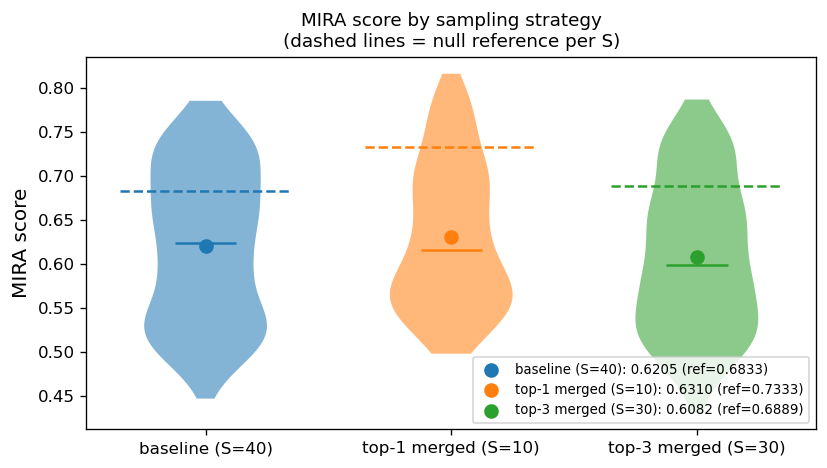

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["C0", "C1", "C2"]
for (label, (scores, ref)), color in zip(mira_results.items(), colors):
    parts = ax.violinplot([scores], positions=[list(mira_results).index(label)],
                          showmedians=True, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(color); pc.set_alpha(0.55)
    ax.scatter(list(mira_results).index(label), scores.mean(),
               color=color, zorder=5, s=60, label=f"{label}: {scores.mean():.4f} (ref={ref:.4f})")
    ax.hlines(ref, list(mira_results).index(label) - 0.35,
              list(mira_results).index(label) + 0.35,
              colors=color, linestyles="--", lw=1.5)

ax.set_xticks(range(len(mira_results)))
ax.set_xticklabels(list(mira_results.keys()), fontsize=10)
ax.set_ylabel("MIRA score", fontsize=12)
ax.set_title("MIRA score by sampling strategy\n(dashed lines = null reference per S)", fontsize=11)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(f"{FIGURES}/mira_sampling_strategy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()